# 00 — Setup & Benchmark

This project compares Continual Learning (CL) strategies implemented in
[Avalanche](https://github.com/ContinualAI/avalanche) — the classic
regularization / replay / architectural families — against a new demo
strategy, **Skill Memory**, proposed in
[`skill_memory_algorithm.md`](https://github.com/kobros-tech/avalanche/blob/feature/skill-memory-prototype/docs/skill_memory_algorithm.md).

**Notebooks in this project:**

| # | Notebook | What it covers |
|---|----------|-----------------|
| 00 | `00_setup_and_benchmark` | Environment check + the benchmark used everywhere else |
| 01 | `01_baselines` | Naive, Cumulative, JointTraining |
| 02 | `02_regularization_strategies` | EWC, Synaptic Intelligence, LwF |
| 03 | `03_replay_strategies` | Replay, GEM, A-GEM, GDumb |
| 04 | `04_architectural_strategies` | CWR\*, AR1 |
| 05 | `05_skill_memory_demo` | The new Skill Memory strategy: mechanism tests, oracle-transfer demo, automatic policy |
| 06 | `06_comparison_dashboard` | Aggregates every notebook's `results/*.csv` into one comparison |

**Why a synthetic benchmark?** This sandbox has no network access to
download MNIST/CIFAR, so `src/skill_memory/synthetic_benchmark.py`
generates a small in-memory class-incremental benchmark (Gaussian blobs
per class) using Avalanche's own `nc_benchmark` generator. Every notebook
is otherwise benchmark-agnostic — swap in `avalanche.benchmarks.SplitMNIST(...)`
(or any classic benchmark) wherever you have real dataset access, and
everything else keeps working unchanged.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import avalanche, torch
print('avalanche', avalanche.__version__)
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())


avalanche 0.6.0
torch 2.13.0+cu130
cuda available: False


## Build the shared benchmark

5 experiences, 10 classes total (2 new classes per experience), 20-D features.

In [2]:
from skill_memory.synthetic_benchmark import make_synthetic_benchmark

N_EXPERIENCES = 5
N_CLASSES = 10
INPUT_DIM = 20

benchmark, input_dim, n_classes = make_synthetic_benchmark(
    n_experiences=N_EXPERIENCES,
    n_classes=N_CLASSES,
    input_dim=INPUT_DIM,
    train_samples_per_class=150,
    test_samples_per_class=60,
    seed=0,
)

for exp in benchmark.train_stream:
    print(f'train exp {exp.current_experience}: classes={exp.classes_in_this_experience} '
          f'n={len(exp.dataset)}')


train exp 0: classes=[1, 4] n=300
train exp 1: classes=[5, 7] n=300
train exp 2: classes=[9, 3] n=300
train exp 3: classes=[0, 8] n=300
train exp 4: classes=[2, 6] n=300


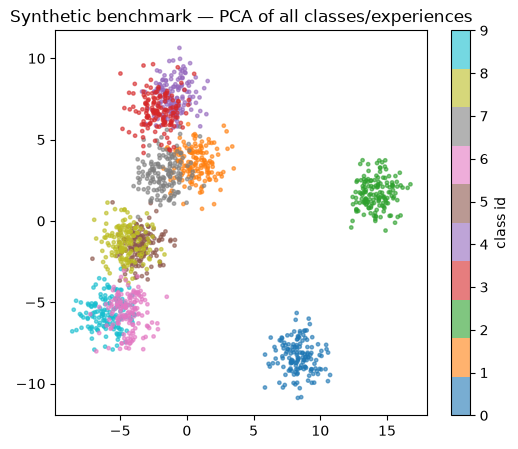

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Quick 2D PCA visualization of class separation, just as a sanity check.
all_x, all_y, all_exp = [], [], []
for exp in benchmark.train_stream:
    for x, y, *_ in exp.dataset:
        all_x.append(x.numpy())
        all_y.append(int(y))
        all_exp.append(exp.current_experience)
all_x = np.stack(all_x)

pca = PCA(n_components=2).fit(all_x)
proj = pca.transform(all_x)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(proj[:, 0], proj[:, 1], c=all_y, cmap='tab10', s=6, alpha=0.6)
ax.set_title('Synthetic benchmark — PCA of all classes/experiences')
plt.colorbar(sc, label='class id')
plt.show()


## Shared model factory

Every strategy in notebooks 01-05 uses the *same* small MLP architecture
and the *same* benchmark, so accuracy/forgetting numbers are comparable
across notebooks in `06_comparison_dashboard`.

In [4]:
import torch.nn as nn

def model_factory():
    return nn.Sequential(
        nn.Linear(input_dim, 32),
        nn.ReLU(),
        nn.Linear(32, n_classes),
    )

model_factory()


Sequential(
  (0): Linear(in_features=20, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=10, bias=True)
)

This benchmark + `model_factory` are re-built identically (same seed) at the top of every other notebook, so notebooks can be run independently and in any order.